# Adjacent-frame grayscale difference video (streaming, faster, easier to debug)

This version avoids loading the whole video into a giant `(H, W, T)` array.

What changed:
- **Streams frame by frame** instead of storing the whole video in memory.
- Uses **OpenCV grayscale conversion + `cv2.absdiff`** for fast adjacent-frame differencing.
- Keeps **full temporal resolution**: if the input has `N` frames, the output has `N-1` diff frames.
- Lets you optionally **resize spatially** to speed things up, without skipping frames.
- Breaks the pipeline into **small functions** so each step is easy to debug.

The output MP4 contains the **absolute grayscale brightness difference** between each frame and the one immediately before it.


In [1]:
import cv2
import numpy as np

In [2]:

import cv2
import numpy as np
from dataclasses import dataclass
from pathlib import Path
from typing import Generator, Optional, Tuple


@dataclass
class VideoInfo:
    path: str
    width: int
    height: int
    fps: float
    frame_count: int


def get_video_info(video_path: str) -> VideoInfo:
    """
    Read basic metadata from a video file.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    info = VideoInfo(
        path=video_path,
        width=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        height=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        fps=float(cap.get(cv2.CAP_PROP_FPS)) or 30.0,
        frame_count=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
    )
    cap.release()

    if info.width <= 0 or info.height <= 0:
        raise ValueError(f"Invalid video dimensions for: {video_path}")

    return info


def compute_output_size(
    original_size: Tuple[int, int],
    scale: float = 1.0,
    target_size: Optional[Tuple[int, int]] = None,
) -> Tuple[int, int]:
    """
    Compute the output frame size.

    Args:
        original_size: (width, height)
        scale: Resize factor applied if target_size is None.
        target_size: Explicit (width, height). Overrides scale.

    Returns:
        (width, height)
    """
    if target_size is not None:
        out_w, out_h = target_size
    else:
        in_w, in_h = original_size
        out_w = max(1, int(round(in_w * scale)))
        out_h = max(1, int(round(in_h * scale)))

    if out_w <= 0 or out_h <= 0:
        raise ValueError("Output size must be positive.")

    return int(out_w), int(out_h)


def open_video_reader(video_path: str) -> cv2.VideoCapture:
    """
    Open a video for frame-by-frame reading.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    return cap


def bgr_to_gray(frame_bgr: np.ndarray) -> np.ndarray:
    """
    Convert a BGR frame to grayscale uint8.
    """
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)


def resize_gray_frame(
    gray_frame: np.ndarray,
    output_size: Tuple[int, int],
    interpolation: int = cv2.INTER_AREA,
) -> np.ndarray:
    """
    Resize a grayscale frame.
    """
    return cv2.resize(gray_frame, output_size, interpolation=interpolation)


def preprocess_frame(
    frame_bgr: np.ndarray,
    output_size: Optional[Tuple[int, int]] = None,
) -> np.ndarray:
    """
    Convert a BGR frame to grayscale and optionally resize it.
    """
    gray = bgr_to_gray(frame_bgr)
    if output_size is not None:
        gray = resize_gray_frame(gray, output_size)
    return gray


def adjacent_gray_differences(
    video_path: str,
    scale: float = 1.0,
    target_size: Optional[Tuple[int, int]] = None,
) -> Generator[np.ndarray, None, VideoInfo]:
    """
    Yield absolute grayscale brightness differences between adjacent frames.

    This streams through the video and only keeps one previous frame in memory.
    Temporal resolution is preserved: for N input frames, this yields N-1 diff frames.

    Args:
        video_path: Input video path.
        scale: Spatial resize factor. Ignored if target_size is provided.
        target_size: Optional explicit output size (width, height).

    Yields:
        diff_gray: uint8 image of abs(gray_t - gray_{t-1})
    """
    info = get_video_info(video_path)
    output_size = compute_output_size((info.width, info.height), scale=scale, target_size=target_size)

    cap = open_video_reader(video_path)
    try:
        ok, first_frame = cap.read()
        if not ok:
            raise ValueError(f"No frames could be read from: {video_path}")

        prev_gray = preprocess_frame(first_frame, output_size=output_size)

        while True:
            ok, frame = cap.read()
            if not ok:
                break

            curr_gray = preprocess_frame(frame, output_size=output_size)

            # Fast absolute difference in C/OpenCV.
            diff_gray = cv2.absdiff(curr_gray, prev_gray)

            yield diff_gray
            prev_gray = curr_gray
    finally:
        cap.release()


def open_gray_video_writer(
    output_path: str,
    frame_size: Tuple[int, int],
    fps: float,
    codec: str = "mp4v",
) -> cv2.VideoWriter:
    """
    Open an MP4 writer. Grayscale frames are written as 3-channel BGR
    because OpenCV's MP4 writing is more reliable that way.
    """
    fourcc = cv2.VideoWriter_fourcc(*codec)
    writer = cv2.VideoWriter(output_path, fourcc, fps, frame_size, isColor=True)
    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter for: {output_path}")
    return writer


def gray_to_bgr(gray_frame: np.ndarray) -> np.ndarray:
    """
    Convert single-channel grayscale image to 3-channel BGR for video writing.
    """
    return cv2.cvtColor(gray_frame, cv2.COLOR_GRAY2BGR)


def write_diff_video(
    input_video_path: str,
    output_video_path: str,
    scale: float = 1.0,
    target_size: Optional[Tuple[int, int]] = None,
    codec: str = "mp4v",
    show_progress_every: int = 100,
) -> dict:
    """
    Create an MP4 whose frames are the grayscale absolute differences between
    adjacent input frames.

    Args:
        input_video_path: Source video.
        output_video_path: Destination mp4 path.
        scale: Spatial resize factor before differencing.
        target_size: Optional explicit output size (width, height).
        codec: MP4 codec string.
        show_progress_every: Print progress every N diff frames.

    Returns:
        Dictionary with output metadata.
    """
    info = get_video_info(input_video_path)
    output_size = compute_output_size((info.width, info.height), scale=scale, target_size=target_size)

    writer = open_gray_video_writer(
        output_path=output_video_path,
        frame_size=output_size,
        fps=info.fps,
        codec=codec,
    )

    num_written = 0
    try:
        for diff_gray in adjacent_gray_differences(
            input_video_path,
            scale=scale,
            target_size=target_size,
        ):
            writer.write(gray_to_bgr(diff_gray))
            num_written += 1

            if show_progress_every and num_written % show_progress_every == 0:
                print(f"Wrote {num_written} diff frames...")
    finally:
        writer.release()

    result = {
        "input_path": input_video_path,
        "output_path": output_video_path,
        "input_size": (info.width, info.height),
        "output_size": output_size,
        "input_fps": info.fps,
        "input_frame_count": info.frame_count,
        "output_frame_count": num_written,
        "codec": codec,
    }

    print("Done.")
    print(result)
    return result


def sample_diff_frames(
    video_path: str,
    n_samples: int = 6,
    scale: float = 1.0,
    target_size: Optional[Tuple[int, int]] = None,
) -> list:
    """
    Grab a few diff frames for debugging/visual inspection without writing a video.
    """
    diffs = []
    gen = adjacent_gray_differences(video_path, scale=scale, target_size=target_size)
    for i, diff_gray in enumerate(gen):
        diffs.append(diff_gray)
        if len(diffs) >= n_samples:
            break
    return diffs


In [5]:
# Set your paths here
input_video_path = "Raja vs Wijemanne short.mp4"
output_video_path = "diff short.mp4"

# Example 1: full spatial resolution
result = write_diff_video(
    input_video_path=input_video_path,
    output_video_path=output_video_path,
    scale=1.0,          # keep original size
    target_size=None,   # or set something like (640, 360)
    codec="mp4v",
    show_progress_every=100,
)

result

Wrote 100 diff frames...
Wrote 200 diff frames...
Wrote 300 diff frames...
Wrote 400 diff frames...
Wrote 500 diff frames...
Wrote 600 diff frames...
Wrote 700 diff frames...
Wrote 800 diff frames...
Wrote 900 diff frames...
Wrote 1000 diff frames...
Wrote 1100 diff frames...
Wrote 1200 diff frames...
Wrote 1300 diff frames...
Done.
{'input_path': 'Raja vs Wijemanne short.mp4', 'output_path': 'diff short.mp4', 'input_size': (1920, 1080), 'output_size': (1920, 1080), 'input_fps': 24.98337070674549, 'input_frame_count': 1320, 'output_frame_count': 1301, 'codec': 'mp4v'}


{'input_path': 'Raja vs Wijemanne short.mp4',
 'output_path': 'diff short.mp4',
 'input_size': (1920, 1080),
 'output_size': (1920, 1080),
 'input_fps': 24.98337070674549,
 'input_frame_count': 1320,
 'output_frame_count': 1301,
 'codec': 'mp4v'}

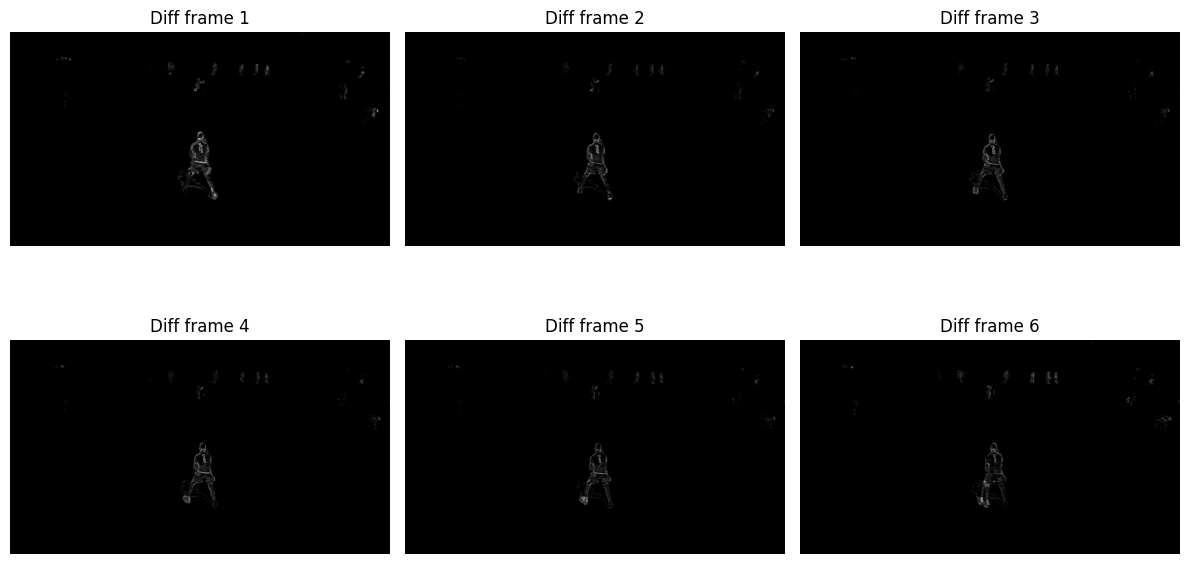

In [4]:
import matplotlib.pyplot as plt

# Inspect a few difference frames before writing the whole video
debug_diffs = sample_diff_frames(
    video_path=input_video_path,
    n_samples=6,
    scale=1.0,
    target_size=None,
)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, diff_frame, idx in zip(axes.ravel(), debug_diffs, range(len(debug_diffs))):
    ax.imshow(diff_frame, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Diff frame {idx + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()
